In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [20]:
#  data loading
df: pd.DataFrame = pd.read_csv('../datasets/heart.csv')

In [21]:
#  form train and test sets
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
#  checking for classes balance
print(f"training set balance:\n {y_train.value_counts()}")
print(f"test set balance:\n {y_test.value_counts()}")

training set balance:
 target
1    133
0    109
Name: count, dtype: int64
test set balance:
 target
1    32
0    29
Name: count, dtype: int64


In [23]:
#  common method for readable confusion matrix
def create_cm_with_labels(cm):
    return pd.DataFrame(
        [
            [f"{cm[0,0]} (TN)", f"{cm[0,1]} (FP)"],
            [f"{cm[1,0]} (FN)", f"{cm[1,1]} (TP)"],
        ],
        index=["Actual Negative", "Actual Positive"],
        columns=["Predicted Negative", "Predicted Positive"]
    )

Gaussian Bayes model

In [24]:
# Model training
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
y_gnb_pred = gnb_model.predict(X_test)

In [25]:
# Evaluation metrics
gnb_accuracy = accuracy_score(y_test, y_gnb_pred)
gnb_recall = recall_score(y_test, y_gnb_pred)
gnb_precision = precision_score(y_test, y_gnb_pred)
gnb_f1 = f1_score(y_test, y_gnb_pred)

print(f"Accuracy: {gnb_accuracy:.4f}")
print(f"Recall: {gnb_recall:.4f}")
print(f"Precision: {gnb_precision:.4f}")
print(f"F1 Score: {gnb_f1:.4f}")

Accuracy: 0.8689
Recall: 0.8438
Precision: 0.9000
F1 Score: 0.8710


In [26]:
# Confusion matrix
gnb_cm = confusion_matrix(y_test, y_gnb_pred)
print("\nConfusion Matrix:")
print(create_cm_with_labels(gnb_cm))
print(f"Count of incorrect prediction by Gaussian Bayes model: {(y_gnb_pred != y_test).sum()} from {X_test.shape[0]}")


Confusion Matrix:
                Predicted Negative Predicted Positive
Actual Negative            26 (TN)             3 (FP)
Actual Positive             5 (FN)            27 (TP)
Count of incorrect prediction by Gaussian Bayes model: 8 from 61


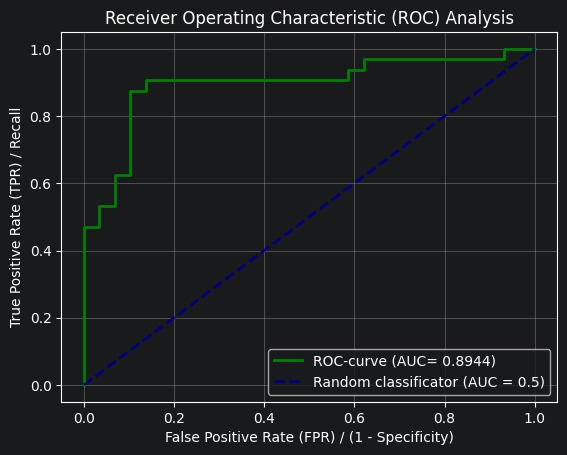

In [27]:
# ROC analysis
y_probs = gnb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC-curve (AUC= {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR) / (1 - Specificity)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Analysis')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Logistic regression


In [28]:
#  Model training
logreg_model = LogisticRegression(l1_ratio=0, solver='lbfgs', max_iter=3000, random_state=42)
logreg_model.fit(X_train, y_train)
y_logreg_pred = logreg_model.predict(X_test)

In [29]:
# Evaluation metrics
logreg_accuracy = accuracy_score(y_test, y_logreg_pred)
logreg_recall = recall_score(y_test, y_logreg_pred)
logreg_precision = precision_score(y_test, y_logreg_pred)
logreg_f1 = f1_score(y_test, y_logreg_pred)

print(f"Accuracy: {logreg_accuracy:.4f}")
print(f"Recall: {logreg_recall:.4f}")
print(f"Precision: {logreg_precision:.4f}")
print(f"F1 Score: {logreg_f1:.4f}")

Accuracy: 0.8852
Recall: 0.9062
Precision: 0.8788
F1 Score: 0.8923


In [30]:
# Confusion matrix
logreg_cm = confusion_matrix(y_test, y_logreg_pred)

print("\nConfusion Matrix:")
print(create_cm_with_labels(logreg_cm))
print(f"Count of incorrect prediction by logistic regression model: {(y_logreg_pred != y_test).sum()} from {X_test.shape[0]}")


Confusion Matrix:
                Predicted Negative Predicted Positive
Actual Negative            25 (TN)             4 (FP)
Actual Positive             3 (FN)            29 (TP)
Count of incorrect prediction by logistic regression model: 7 from 61


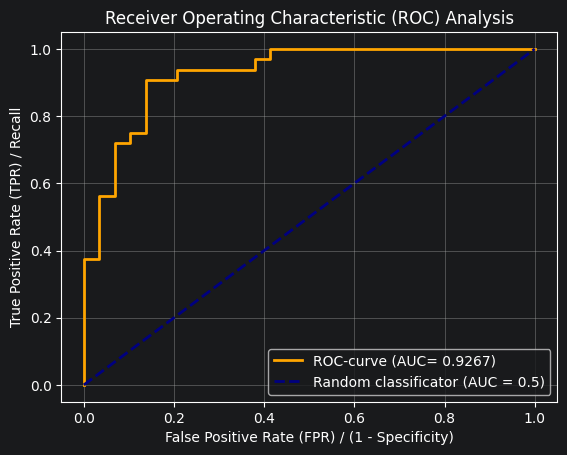

In [31]:
# ROC analysis
y_probs = logreg_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC-curve (AUC= {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR) / (1 - Specificity)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Analysis')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

K neighbors classifier

In [32]:
# Model training
scaler = StandardScaler()
accuracy_series = []

for k in range(1, len(y_test)):
    knn = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_knn)
    accuracy_series.append([k, accuracy])

best_accuracy = max(accuracy_series, key=lambda x: x[1])
best_k = best_accuracy[0]

knn_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

In [33]:
# Evaluation metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"F1 Score: {knn_f1:.4f}")

Accuracy: 0.9180
Recall: 0.9062
Precision: 0.9355
F1 Score: 0.9206


In [34]:
# Confusion matrix
knn_cm = confusion_matrix(y_test, y_pred_knn)

In [35]:
print("\nConfusion Matrix:")
print(create_cm_with_labels(knn_cm))
print(f"Count of incorrect prediction by logistic regression model: {(y_pred_knn != y_test).sum()} from {X_test.shape[0]}")


Confusion Matrix:
                Predicted Negative Predicted Positive
Actual Negative            27 (TN)             2 (FP)
Actual Positive             3 (FN)            29 (TP)
Count of incorrect prediction by logistic regression model: 5 from 61


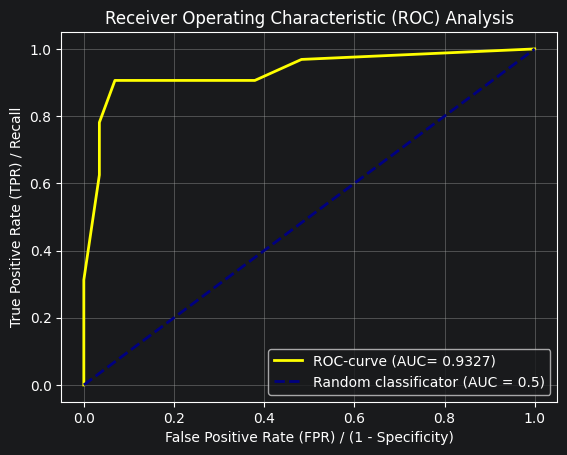

In [36]:
# ROC analysis
y_probs = knn_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='yellow', lw=2, label=f'ROC-curve (AUC= {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR) / (1 - Specificity)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Analysis')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()